# Pixel Art PFP Generator — data pipeline, training, export

Companion notebook to `PIXEL_ART_GENERATION_PLAN.md`. Sections:

1. Environment & config
2. Generate source images (FLUX.1-schnell, SD-Turbo fallback)
3. Pixelise + quantise to ≤9 palette indices (32 and 64)
4. Dataset
5. Masked discrete diffusion transformer
6. Train
7. Sample & visualise
8. Export to ONNX

> Drafted without network access: library APIs were not verified against current versions. If a call fails, check the current `diffusers` / `onnx` docs before assuming the logic is wrong.

## 0. Validate CUDA before running anything

Run the two cells below first. Do not proceed to section 2 until every check passes.

**What "pass" looks like**
- `torch.cuda.is_available()` → `True`
- `torch.version.cuda` shows a version (e.g. `12.4`), not `None`
- Your card name and VRAM are printed
- The matmul test finishes in well under a second and prints a device of `cuda:0`
- `bf16 supported` → `True` on Ampere (RTX 30xx) or newer; `False` is fine, the notebook falls back to fp16

**If `is_available()` is `False`**
1. Check the driver: run `nvidia-smi` in a terminal. If it errors, install/update the NVIDIA driver first.
2. Check the torch build: `torch.version.cuda` being `None` means you have the CPU-only wheel. Reinstall with the CUDA wheel from https://pytorch.org/get-started/locally/ (pick the CUDA version ≤ the "CUDA Version" shown by `nvidia-smi`), e.g.
   `pip install --force-reinstall torch torchvision --index-url https://download.pytorch.org/whl/cu124`
3. Check the kernel: in VS Code, confirm the notebook kernel (top right) is the same environment you installed torch into. Restart the kernel after reinstalling.

**VRAM guidance (from the printed figure)**
- ≥ 24 GB: comment out `pipe.enable_model_cpu_offload()` in section 2 for faster generation.
- 12–24 GB: leave CPU offload on (default).
- < 12 GB: FLUX may still fail even with offload; set `USE_SD_TURBO = True` in section 2. Also lower `batch` in `CONFIGS` for the 64px model.


In [13]:
# 0a. Driver / toolkit view (runs the CLI; safe to skip if it errors, but then fix the driver)
!nvidia-smi


Fri Sep 18 18:31:10 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 590.57                 Driver Version: 591.86         CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4080 ...    On  |   00000000:01:00.0  On |                  N/A |
|  0%   36C    P8             16W /  320W |   12017MiB /  16376MiB |      2%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [14]:
# 0b. PyTorch CUDA checks — must all pass
import torch, time
print("torch version      :", torch.__version__)
print("torch CUDA build   :", torch.version.cuda)          # None => CPU-only wheel installed
print("cuda available     :", torch.cuda.is_available())
assert torch.cuda.is_available(), "CUDA not available to PyTorch - see instructions above"

p = torch.cuda.get_device_properties(0)
print("device             :", p.name)
print("VRAM               :", f"{p.total_memory/1e9:.1f} GB")
print("compute capability :", f"{p.major}.{p.minor}")
print("bf16 supported     :", torch.cuda.is_bf16_supported())
print("cuDNN version      :", torch.backends.cudnn.version())

# real work on the GPU, timed
x = torch.randn(4096, 4096, device="cuda")
torch.cuda.synchronize(); t = time.time()
y = x @ x
torch.cuda.synchronize()
print("4096x4096 matmul   :", f"{(time.time()-t)*1000:.1f} ms on", y.device)
assert str(y.device).startswith("cuda"), "tensor did not land on the GPU"

# fused attention kernels (needed for the 64px model at 4k tokens)
from torch.nn.attention import sdpa_kernel, SDPBackend
q = torch.randn(1, 8, 4096, 48, device="cuda", dtype=torch.float16)
ok = {}
for name, be in [("flash", SDPBackend.FLASH_ATTENTION), ("mem_efficient", SDPBackend.EFFICIENT_ATTENTION)]:
    try:
        with sdpa_kernel(be):
            torch.nn.functional.scaled_dot_product_attention(q, q, q)
        ok[name] = True
    except Exception as e:
        ok[name] = False
print("fused SDPA backends:", ok, "(at least one True is needed for the 64px config)")
print("\nALL CUDA CHECKS PASSED")


torch version      : 2.14.0+cu130
torch CUDA build   : 13.0
cuda available     : True
device             : NVIDIA GeForce RTX 4080 SUPER
VRAM               : 17.2 GB
compute capability : 8.9
bf16 supported     : True
cuDNN version      : 92400
4096x4096 matmul   : 135.4 ms on cuda:0
fused SDPA backends: {'flash': True, 'mem_efficient': True} (at least one True is needed for the 64px config)

ALL CUDA CHECKS PASSED


In [3]:
# 1. Environment
# pip install torch torchvision diffusers transformers accelerate pillow numpy scikit-learn matplotlib onnx onnxruntime
import os, json, math, random, time
from pathlib import Path
import numpy as np, torch, torch.nn as nn, torch.nn.functional as F
from PIL import Image

print(torch.__version__, torch.cuda.is_available())
if torch.cuda.is_available():
    p = torch.cuda.get_device_properties(0)
    print(p.name, f"{p.total_memory/1e9:.1f} GB VRAM")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


2.14.0+cu130 True
NVIDIA GeForce RTX 4080 SUPER 17.2 GB VRAM


In [4]:
# 1b. Config

ROOT = Path("../pfp_data"); ROOT.mkdir(exist_ok=True)
RAW_DIR = ROOT / "raw"; RAW_DIR.mkdir(exist_ok=True)
RUN_NAME = "v6_500"
RAW_DIR  = ROOT / RUN_NAME / "raw"; RAW_DIR.mkdir(parents=True, exist_ok=True)
meta_path = ROOT / RUN_NAME / "labels.jsonl"

N_IMAGES      = 4500        # start small to validate; raise to 5000-10000 for the real run
GEN_RES       = 512
GRID_SIZES    = [32, 64]
MAX_COLOURS   = 9           # non-background indices; index 0 = background
BG_THRESHOLD  = 40          # max(R,G,B) below this -> background
MIN_FG_FRAC   = 0.10        # reject images with less foreground than this
SEED          = 1234

VOCAB = {
    "hair":       ["short", "long", "curly", "bald", "mohawk", "ponytail", "afro", "bob"],
    "headwear":   ["none", "cap", "beanie", "crown", "hood", "helmet", "headband", "top hat"],
    "accessory":  ["none", "glasses", "sunglasses", "earring", "headphones", "eyepatch", "scarf", "mask"],
    "expression": ["neutral", "smiling", "frowning", "surprised", "angry", "winking"],
}

HAIR_COLOURS   = ["bright pink", "electric blue", "vivid purple", "neon green", "bright orange",
                  "platinum blonde", "ginger red", "turquoise", "lilac", "golden blonde"]
CLOTH_COLOURS  = ["bright red", "yellow", "white", "orange", "hot pink", "sky blue",
                  "lime green", "cream", "coral", "light grey"]
HAT_COLOURS    = ["red", "yellow", "white", "orange", "bright blue", "pink", "lime green"]

ATTRS = list(VOCAB.keys())
ATTR_SIZES = [len(VOCAB[a]) for a in ATTRS]
json.dump(VOCAB, open(ROOT / "vocab.json", "w"), indent=2)

def build_prompt(lab):
    parts = [
        "close-up studio portrait photograph of one person, head and shoulders, "
        "face filling the frame, centered, looking directly at the camera",
    ]
    if lab["hair"] == "bald":
        parts.append("bald head")
    else:
        parts.append(f"{lab['hair_colour']} {lab['hair']} hair")
    if lab["headwear"]  != "none": parts.append(f"wearing a {lab['hat_colour']} {lab['headwear']}")
    if lab["accessory"] != "none": parts.append(f"wearing {lab['accessory']}")
    parts += [
        f"{lab['expression']} expression",
        f"wearing a {lab['cloth_colour']} top",
        "photorealistic, realistic skin texture, bright key light on the face with soft shadows, "
        "strong rim light outlining the head and shoulders, high contrast against a solid black background, "
        "85mm lens, sharp focus",
    ]
    return ", ".join(parts)

def build_clip_prompt(lab):
    hair = "bald head" if lab["hair"] == "bald" else f"{lab['hair_colour']} hair"
    return (f"close-up photo portrait, {hair}, {lab['cloth_colour']} top, "
            f"rim light, solid black background, photorealistic")

random.seed(SEED)
labels = [{**{a: random.choice(VOCAB[a]) for a in ATTRS},
           "hair_colour":  random.choice(HAIR_COLOURS),
           "cloth_colour": random.choice(CLOTH_COLOURS),
           "hat_colour":   random.choice(HAT_COLOURS)} for _ in range(N_IMAGES)]
print(build_prompt(labels[0]))


close-up studio portrait photograph of one person, head and shoulders, face filling the frame, centered, looking directly at the camera, golden blonde bob hair, wearing a pink cap, neutral expression, wearing a bright red top, photorealistic, realistic skin texture, bright key light on the face with soft shadows, strong rim light outlining the head and shoulders, high contrast against a solid black background, 85mm lens, sharp focus


## 2. Generate source images

Uses FLUX.1-schnell (Apache-2.0). `enable_model_cpu_offload()` is on by default so it fits smaller cards at the cost of speed; comment it out on ≥24 GB. Set `USE_SD_TURBO = True` if FLUX won't fit at all (note SD-Turbo's non-commercial licence).

In [17]:
from dotenv import load_dotenv
load_dotenv("../../.env")   # loads forest/.env (this notebook runs from forest/pixelart/notebooks/)
assert os.environ.get("HF_TOKEN"), "HF_TOKEN not found - check .env location and variable name"

import gc
if "pipe" in globals():
    del pipe
    gc.collect(); torch.cuda.empty_cache()

USE_SD_TURBO = False
GEN_BATCH = 2

if USE_SD_TURBO:
    from diffusers import AutoPipelineForText2Image
    pipe = AutoPipelineForText2Image.from_pretrained("stabilityai/sd-turbo", torch_dtype=torch.float16).to(DEVICE)
    gen_kwargs = dict(num_inference_steps=2, guidance_scale=0.0)
else:
    from diffusers import FluxPipeline
    NF4_DIR = ROOT / "flux_schnell_nf4"

    if NF4_DIR.exists():                                            # fast path: pre-quantised copy
        pipe = FluxPipeline.from_pretrained(NF4_DIR, torch_dtype=torch.bfloat16).to(DEVICE)
    else:                                                           # first time: quantise, then save
        from diffusers.quantizers import PipelineQuantizationConfig
        quant = PipelineQuantizationConfig(
            quant_backend="bitsandbytes_4bit",
            quant_kwargs={"load_in_4bit": True, "bnb_4bit_quant_type": "nf4",
                          "bnb_4bit_compute_dtype": torch.bfloat16},
            components_to_quantize=["transformer", "text_encoder_2"],
        )
        pipe = FluxPipeline.from_pretrained("black-forest-labs/FLUX.1-schnell",
                                            quantization_config=quant,
                                            torch_dtype=torch.bfloat16).to(DEVICE)
        pipe.save_pretrained(NF4_DIR)

    pipe.set_progress_bar_config(disable=True)                     # no per-image bars
    gen_kwargs = dict(num_inference_steps=4, guidance_scale=0.0, max_sequence_length=256)

done = set()
if meta_path.exists():
    done = {json.loads(l)["file"] for l in open(meta_path)}

t0 = time.time(); n_done = 0
with open(meta_path, "a") as f:
    for start in range(0, N_IMAGES, GEN_BATCH):
        idxs = [i for i in range(start, min(start+GEN_BATCH, N_IMAGES)) if f"{i:06d}.png" not in done]
        if not idxs: continue
        prompts      = [build_prompt(labels[i]) for i in idxs]
        clip_prompts = [build_clip_prompt(labels[i]) for i in idxs]
        g = [torch.Generator(DEVICE).manual_seed(SEED + i) for i in idxs]
        imgs = pipe(prompt=clip_prompts, prompt_2=prompts, height=GEN_RES, width=GEN_RES,
            generator=g, **gen_kwargs).images
        for i, im in zip(idxs, imgs):
            fn = f"{i:06d}.png"
            im.save(RAW_DIR / fn)
            f.write(json.dumps({"file": fn, **labels[i]}) + "\n")
        n_done += len(idxs)
        if n_done % 100 < GEN_BATCH:                                # progress every ~100 images
            print(f"{n_done} images, {(time.time()-t0)/n_done:.2f} s/img, {time.strftime('%H:%M:%S')}")
print("done")


/home/elsabella/forest/fenv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/elsabella/forest/fenv/lib/python3.10/site-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)
Loading pipeline components...: 100%|██████████| 7/7 [00:14<00:00,  2.07s/it]


done


## 3. Pixelise + quantise

Produces both grid sizes from each source image. Background = near-black → 0. Foreground → k-means (k ≤ 9) → clusters sorted dark→light → indices 1..k. **This same algorithm is what the app's new ≤9-colour clamp should implement.**

In [22]:
from sklearn.cluster import KMeans

def luminance(rgb):  # rgb: (...,3) float 0-255
    return 0.299*rgb[...,0] + 0.587*rgb[...,1] + 0.114*rgb[...,2]

def quantise(img_rgb, max_colours=MAX_COLOURS, bg_thresh=BG_THRESHOLD, seed=0):
    """img_rgb: (H,W,3) uint8 -> (H,W) uint8 index grid, or None if rejected."""
    px = img_rgb.reshape(-1, 3).astype(np.float32)
    bg = px.max(axis=1) < bg_thresh
    fg = px[~bg]
    if len(fg) < MIN_FG_FRAC * len(px):
        return None
    k = min(max_colours, len(np.unique(fg, axis=0)))
    km = KMeans(n_clusters=k, n_init=4, random_state=seed).fit(fg)
    order = np.argsort(luminance(km.cluster_centers_))          # dark -> light
    rank = np.empty(k, dtype=np.int64); rank[order] = np.arange(1, k+1)
    out = np.zeros(len(px), dtype=np.uint8)
    out[~bg] = rank[km.labels_]
    return out.reshape(img_rgb.shape[:2])

def pixelise(pil_img, size):
    w, h = pil_img.size; s = min(w, h)
    im = pil_img.crop(((w-s)//2, (h-s)//2, (w-s)//2+s, (h-s)//2+s))
    return np.asarray(im.resize((size, size), Image.BOX).convert("RGB"))

recs = [json.loads(l) for l in open(meta_path)]
grids = {s: [] for s in GRID_SIZES}; lab_ids = []; kept = 0
for r in recs:
    im = Image.open(RAW_DIR / r["file"])
    per_size = {s: quantise(pixelise(im, s)) for s in GRID_SIZES}
    if any(v is None for v in per_size.values()):
        continue
    for s in GRID_SIZES: grids[s].append(per_size[s])
    lab_ids.append([VOCAB[a].index(r[a]) for a in ATTRS]); kept += 1
for s in GRID_SIZES:
    np.save(ROOT / f"grids_{s}.npy", np.stack(grids[s]))
np.save(ROOT / "labels.npy", np.array(lab_ids, dtype=np.int64))
print(f"kept {kept}/{len(recs)}")


kept 4500/4500


32 (4500, 32, 32) max index 9


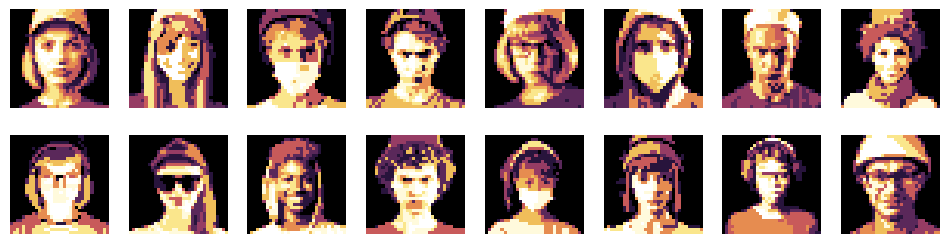

64 (4500, 64, 64) max index 9


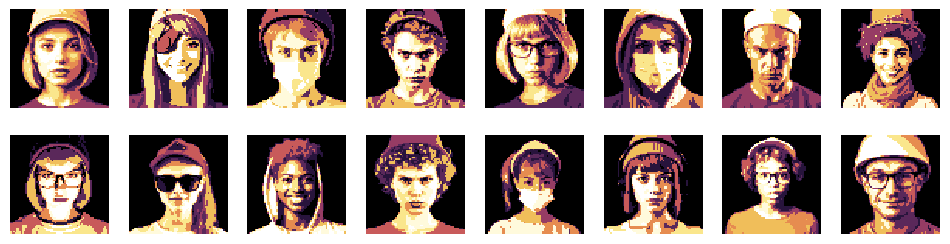

In [23]:
# Quick visual check with a throwaway palette
import matplotlib.pyplot as plt
DEMO_PALETTE = np.array([[0,0,0],[40,20,60],[90,40,90],[150,60,100],[200,90,90],
                         [230,140,80],[240,190,90],[250,230,140],[255,250,220],[255,255,255]], dtype=np.uint8)
def show(grid_batch, ncol=8, palette=DEMO_PALETTE):
    n = len(grid_batch); nrow = math.ceil(n/ncol)
    fig, ax = plt.subplots(nrow, ncol, figsize=(ncol*1.5, nrow*1.5))
    for i, a in enumerate(ax.flat):
        a.axis("off")
        if i < n: a.imshow(palette[grid_batch[i]], interpolation="nearest")
    plt.show()
for s in GRID_SIZES:
    g = np.load(ROOT / f"grids_{s}.npy"); print(s, g.shape, "max index", g.max())
    show(g[:16])


## 4. Dataset

In [6]:
class GridDS(torch.utils.data.Dataset):
    def __init__(self, size):
        self.g = torch.from_numpy(np.load(ROOT / f"grids_{size}.npy")).long().flatten(1)  # (N, L)
        self.y = torch.from_numpy(np.load(ROOT / "labels.npy")).long()                    # (N, 4)
    def __len__(self): return len(self.g)
    def __getitem__(self, i): return self.g[i], self.y[i]


## 5. Model — masked discrete diffusion transformer

Bidirectional encoder over `[4 attribute tokens] + [grid² pixel tokens]`. Vocab = 10 pixel classes + MASK. Each attribute has an extra *null* id for classifier-free guidance.

In [7]:
N_CLASSES = 10
MASK_ID   = N_CLASSES

class MaskedPixelTransformer(nn.Module):
    def __init__(self, grid, attr_sizes, dim=256, depth=8, heads=8, dropout=0.1):
        super().__init__()
        self.grid, self.L, self.A = grid, grid*grid, len(attr_sizes)
        self.tok = nn.Embedding(N_CLASSES+1, dim)
        self.pos = nn.Parameter(torch.randn(1, self.L, dim) * 0.02)
        self.attr_emb = nn.ModuleList([nn.Embedding(n+1, dim) for n in attr_sizes])  # +1 = null
        self.attr_null = torch.tensor(attr_sizes)                                    # null id per attr
        self.attr_pos = nn.Parameter(torch.randn(1, self.A, dim) * 0.02)
        layer = nn.TransformerEncoderLayer(dim, heads, dim*4, dropout=dropout, activation="gelu",
                                           batch_first=True, norm_first=True)
        self.enc = nn.TransformerEncoder(layer, depth, enable_nested_tensor=False)
        self.norm = nn.LayerNorm(dim)
        self.head = nn.Linear(dim, N_CLASSES)

    def forward(self, tokens, attrs):
        # tokens (B,L) int64 in [0..MASK_ID]; attrs (B,A) int64 -> logits (B,L,N_CLASSES)
        a = torch.stack([e(attrs[:, i]) for i, e in enumerate(self.attr_emb)], 1) + self.attr_pos
        x = self.tok(tokens) + self.pos
        h = self.enc(torch.cat([a, x], 1))
        return self.head(self.norm(h[:, self.A:]))

CONFIGS = {
    32: dict(dim=256, depth=8,  heads=8,  batch=64, steps=20000),
    64: dict(dim=384, depth=12, heads=12, batch=16, steps=10000),
}
def make_model(size):
    c = CONFIGS[size]
    m = MaskedPixelTransformer(size, ATTR_SIZES, c["dim"], c["depth"], c["heads"])
    print(size, f"{sum(p.numel() for p in m.parameters())/1e6:.1f}M params")
    return m


## 6. Train

In [11]:
def mask_schedule(u):           # cosine: fraction of tokens masked at "time" u in [0,1]
    return torch.cos(u * math.pi / 2)

def train(size, attr_drop=0.1, lr=3e-4, ema_decay=0.999, log_every=200, resume=None):
    cfg = CONFIGS[size]
    ds = GridDS(size)
    dl = torch.utils.data.DataLoader(ds, batch_size=min(cfg["batch"], len(ds)), shuffle=True, drop_last=False, num_workers=2)
    model = make_model(size).to(DEVICE)
    ema = make_model(size).to(DEVICE); ema.load_state_dict(model.state_dict()); ema.eval()
    for p in ema.parameters(): p.requires_grad_(False)
    if resume is not None:
        ck = torch.load(resume, map_location=DEVICE)
        model.load_state_dict(ck["model"]); ema.load_state_dict(ck["ema"])
        print(f"resumed from step {ck['step']}")
    opt = torch.optim.AdamW(model.parameters(), lr=lr, betas=(0.9, 0.96), weight_decay=0.03)
    total = cfg["steps"]; warm = 500
    sched = torch.optim.lr_scheduler.LambdaLR(opt, lambda s: min(1, s/warm) * 0.5*(1+math.cos(math.pi*min(s,total)/total)))
    scaler_dtype = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
    null = torch.tensor(ATTR_SIZES, device=DEVICE)
    step = 0; t0 = time.time()
    while step < total:
        for g, y in dl:
            g, y = g.to(DEVICE), y.to(DEVICE)
            B, L = g.shape
            # mask
            u = torch.rand(B, device=DEVICE)
            n_mask = (mask_schedule(u) * L).clamp(min=1).long()
            scores = torch.rand(B, L, device=DEVICE)
            thresh = scores.sort(dim=1).values.gather(1, (n_mask-1).unsqueeze(1))
            m = scores <= thresh
            inp = g.masked_fill(m, MASK_ID)
            # attribute dropout for CFG
            drop = torch.rand(B, len(ATTRS), device=DEVICE) < attr_drop
            y_in = torch.where(drop, null.expand_as(y), y)
            with torch.autocast("cuda", dtype=scaler_dtype, enabled=(DEVICE=="cuda")):
                logits = model(inp, y_in)
                loss = F.cross_entropy(logits[m], g[m])
            opt.zero_grad(set_to_none=True); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step(); sched.step(); step += 1
            with torch.no_grad():
                for pe, pm in zip(ema.parameters(), model.parameters()):
                    pe.lerp_(pm, 1-ema_decay)
            if step % log_every == 0:
                print(f"{size}px step {step}/{total} loss {loss.item():.3f} lr {sched.get_last_lr()[0]:.2e} {(time.time()-t0)/60:.1f}min")
            if step % 2000 == 0 or step == total:
                torch.save({"model": model.state_dict(), "ema": ema.state_dict(), "step": step}, ROOT / f"ckpt_{size}.pt")
            if step >= total: break
    return model, ema

# model32, ema32 = train(32)

# CONFIGS[64]["steps"] = 10000
# model64, ema64 = train(64, log_every=250)

# CONFIGS[64]["batch"] = 8
# model64, ema64 = train(64, log_every=250)

# CONFIGS[32]["steps"] = 3000
# model32, ema32 = train(32, log_every=250)

# CONFIGS[64]["batch"] = 8
# CONFIGS[64]["steps"] = 3000
# model64, ema64 = train(64, log_every=250)

CONFIGS[64]["steps"] = 12000
model64, ema64 = train(64, log_every=250, resume=ROOT / "ckpt_64.pt")


64 22.9M params
64 22.9M params
resumed from step 4000
64px step 250/12000 loss 0.693 lr 1.50e-04 2.2min
64px step 500/12000 loss 0.778 lr 2.99e-04 4.4min
64px step 750/12000 loss 0.788 lr 2.97e-04 6.6min
64px step 1000/12000 loss 0.820 lr 2.95e-04 8.8min
64px step 1250/12000 loss 0.956 lr 2.92e-04 11.0min
64px step 1500/12000 loss 0.892 lr 2.89e-04 13.2min
64px step 1750/12000 loss 0.701 lr 2.85e-04 15.4min
64px step 2000/12000 loss 0.729 lr 2.80e-04 17.6min
64px step 2250/12000 loss 0.822 lr 2.75e-04 19.8min
64px step 2500/12000 loss 0.872 lr 2.69e-04 22.0min
64px step 2750/12000 loss 0.742 lr 2.63e-04 24.2min
64px step 3000/12000 loss 0.652 lr 2.56e-04 26.4min
64px step 3250/12000 loss 0.697 lr 2.49e-04 28.6min
64px step 3500/12000 loss 0.706 lr 2.41e-04 30.8min
64px step 3750/12000 loss 0.760 lr 2.33e-04 33.0min
64px step 4000/12000 loss 0.697 lr 2.25e-04 35.2min
64px step 4250/12000 loss 0.626 lr 2.16e-04 37.4min
64px step 4500/12000 loss 0.599 lr 2.07e-04 39.7min
64px step 4750/1

## 7. Sample & visualise

Iterative masked decoding with classifier-free guidance. This loop is what the browser JS reproduces.

In [12]:
model64 = make_model(64).to(DEVICE)
model64.load_state_dict(torch.load(ROOT / "ckpt_64.pt")["model"])

64 22.9M params


<All keys matched successfully>

In [9]:
import matplotlib.pyplot as plt
DEMO_PALETTE = np.array([[0,0,0],[40,20,60],[90,40,90],[150,60,100],[200,90,90],
                         [230,140,80],[240,190,90],[250,230,140],[255,250,220],[255,255,255]], dtype=np.uint8)
def show(grid_batch, ncol=8, palette=DEMO_PALETTE):
    n = len(grid_batch); nrow = math.ceil(n/ncol)
    fig, ax = plt.subplots(nrow, ncol, figsize=(ncol*1.5, nrow*1.5))
    for i, a in enumerate(ax.flat):
        a.axis("off")
        if i < n: a.imshow(palette[grid_batch[i]], interpolation="nearest")
    plt.show()

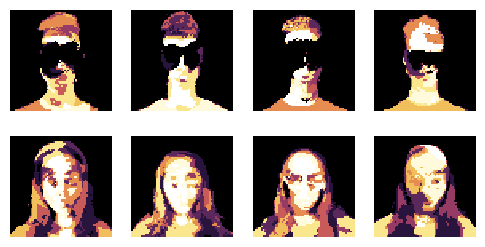

In [15]:
@torch.no_grad()
def sample(model, size, attrs, T=10, cfg_w=1.5, temp=0.8, seed=0):
    """attrs: (B,4) int64 tensor of attribute ids. Returns (B,size,size) uint8 grids."""
    model.eval()
    gen = torch.Generator(DEVICE).manual_seed(seed)
    B, L = attrs.shape[0], size*size
    attrs = attrs.to(DEVICE)
    null = torch.tensor(ATTR_SIZES, device=DEVICE).expand_as(attrs)
    tokens = torch.full((B, L), MASK_ID, device=DEVICE, dtype=torch.long)
    unknown = torch.ones(B, L, dtype=torch.bool, device=DEVICE)
    for t in range(T):
        with torch.autocast("cuda", dtype=torch.bfloat16, enabled=(DEVICE=="cuda")):
            logits = model(torch.cat([tokens, tokens]), torch.cat([attrs, null])).float()
        lc, lu = logits.chunk(2)
        logits = lu + cfg_w * (lc - lu)
        probs = F.softmax(logits / temp, -1)
        pred = torch.multinomial(probs.view(-1, N_CLASSES), 1, generator=gen).view(B, L)
        conf = probs.gather(-1, pred.unsqueeze(-1)).squeeze(-1)
        noise = -torch.log(-torch.log(torch.rand(B, L, generator=gen, device=DEVICE).clamp_min(1e-9)))
        conf = torch.log(conf.clamp_min(1e-9)) + noise * 4.5 * (1 - (t+1)/T)
        conf = conf.masked_fill(~unknown, float("inf"))
        n_remask = int(math.floor(L * math.cos(math.pi/2 * (t+1)/T)))
        tokens = torch.where(unknown, pred, tokens)
        if n_remask > 0:
            idx = conf.argsort(dim=1)[:, :n_remask]
            remask = torch.zeros_like(unknown).scatter_(1, idx, True)
            tokens = tokens.masked_fill(remask, MASK_ID)
            unknown = remask
        else:
            unknown[:] = False
    return tokens.view(B, size, size).to(torch.uint8).cpu().numpy()

def attr_ids(**kw):
    return torch.tensor([[VOCAB[a].index(kw.get(a, VOCAB[a][0])) for a in ATTRS]])

a1 = attr_ids(hair="mohawk", headwear="none", accessory="sunglasses", expression="smiling").repeat(4, 1)
a2 = attr_ids(hair="long", headwear="crown", accessory="none", expression="neutral").repeat(4, 1)
show(sample(model64, 64, torch.cat([a1, a2]), T=16, cfg_w=2.5, temp=0.8, seed=0), ncol=4)

In [14]:
# Sanity checks: colour count and nearest-neighbour memorisation
g = sample(ema32, 32, torch.randint(0, 6, (64, 4)) % torch.tensor(ATTR_SIZES), seed=1)
assert all(len(np.unique(x)) - (0 in x) <= MAX_COLOURS for x in g)
train_g = np.load(ROOT / "grids_32.npy").reshape(len(np.load(ROOT / "grids_32.npy")), -1)
d = (g.reshape(len(g), -1)[:, None, :] != train_g[None]).mean(-1).min(1)
print("min fraction of cells differing from nearest training image:", d.min(), "mean", d.mean())


NameError: name 'ema32' is not defined

## 8. Export to ONNX

Exports the single forward pass. The browser (onnxruntime-web, `webgpu` EP with `wasm` fallback) runs the decoding loop from section 7 in JS with a seeded RNG.

In [30]:
import copy, onnx, onnxruntime as ort

def export(model, size, path):
    m = copy.deepcopy(model).eval().cpu().float()      # don't disturb the live model
    tok = torch.full((2, size*size), MASK_ID, dtype=torch.long)
    att = torch.zeros(2, len(ATTRS), dtype=torch.long)
    batch = torch.export.Dim("batch")
    torch.onnx.export(m, (tok, att), path, opset_version=17, dynamo=True,
                      input_names=["tokens", "attrs"], output_names=["logits"],
                      dynamic_shapes={"tokens": {0: batch}, "attrs": {0: batch}})
    onnx.checker.check_model(onnx.load(path))
    sess = ort.InferenceSession(path, providers=["CPUExecutionProvider"])
    out = sess.run(None, {"tokens": tok.numpy(), "attrs": att.numpy()})[0]
    ref = m(tok, att).detach().numpy()
    print(path, f"{os.path.getsize(path)/1e6:.1f} MB", "max abs diff", np.abs(out-ref).max())
# export(ema64, 64, str(ROOT / "pfp_64.onnx"))


### Next steps outside this notebook
- Port `quantise()` (section 3) to JS as the app's ≤9-colour clamp.
- Implement the section 7 loop in JS over onnxruntime-web; batch the CFG pair as one call of batch size 2.
- Optionally fp16/int8-quantise the ONNX file (`onnxruntime.quantization`) to shrink the download.